# Random Forest: AUC vs n_estimators
This notebook demonstrates how to tune the number of trees (`n_estimators`) in a Random Forest and visualize its impact using ROC-AUC.

Steps:
1. Generate a synthetic dataset
2. Train Random Forest models with different numbers of trees
3. Compute AUC score
4. Plot AUC vs number of trees


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score


## Step 1: Create a Sample Dataset

In [2]:
X, y = make_classification(
    n_samples=2000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Step 2: Train Random Forest with Different n_estimators

In [3]:
n_estimators_list = [10, 50, 100, 200, 300, 500]
auc_scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_prob = rf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_prob)

    auc_scores.append(auc)
    print(f"n_estimators={n}, AUC={auc:.4f}")


n_estimators=10, AUC=0.9542
n_estimators=50, AUC=0.9753
n_estimators=100, AUC=0.9789
n_estimators=200, AUC=0.9779
n_estimators=300, AUC=0.9781
n_estimators=500, AUC=0.9780


## Step 3: Plot AUC vs n_estimators

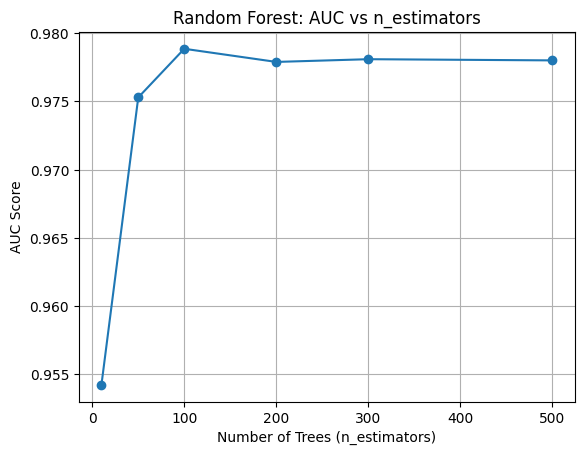

In [4]:
plt.figure()
plt.plot(n_estimators_list, auc_scores, marker='o')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('AUC Score')
plt.title('Random Forest: AUC vs n_estimators')
plt.grid(True)
plt.show()


## Interpretation

- As the number of trees increases, model performance improves.
- After a certain point, the AUC score plateaus.
- Choose the smallest `n_estimators` where the curve stabilizes to balance performance and training cost.
